

*  DSC 530 Data Exploration and Analysis
*  Week 11 - Final Project
*  Adam Luna
* Statistical Analysis of Audio Feature Differences Across Music Genres

This analysis uses the Spotify Tracks dataset obtained from Kaggle.  
The dataset file ("spotify_tracks.csv") is included with the project submission so the notebook can be executed without errors.

Dataset source: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

## Setup



This section imports the Python libraries required for data analysis, visualization, statistical testing, and modeling. These libraries will be used throughout the notebook to load the dataset, explore the data, generate visualizations, and perform statistical and machine learning analyses.

Pandas and NumPy are used for data manipulation and numerical operations. Matplotlib and Seaborn are used to create visualizations that help explore patterns in the data. SciPy provides tools for statistical hypothesis testing. Scikit-learn is used for regression, classification, clustering, and other modeling techniques that support the exploratory data analysis.

In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import statistical testing tools
from scipy import stats

# Import machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import regression and classification models
from sklearn.linear_model import LinearRegression, LogisticRegression

# Import clustering and dimensionality reduction tools
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configure visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

## Load and Inspect Dataset

In this section, the Spotify tracks dataset is loaded into the notebook and inspected to verify that the data was imported correctly. Basic information about the dataset is examined, including the number of observations, available variables, and data types. This initial inspection helps provide an overview of the dataset and ensures that the variables required for analysis are present.

In [2]:
# Load the Spotify tracks dataset into a pandas DataFrame
df = pd.read_csv("spotify_tracks.csv")

# Display the first five rows to preview the dataset
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# Display the number of rows and columns in the dataset
df.shape

(114000, 21)

In [4]:
# Display column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [5]:
# Display the number of songs in each genre
df['track_genre'].value_counts()

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
                     ... 
folk                 1000
emo                  1000
electronic           1000
electro              1000
world-music          1000
Name: count, Length: 114, dtype: int64

## Data Cleaning and Preparation

Before performing exploratory data analysis, the dataset must be cleaned and prepared to ensure that it is suitable for analysis. This process includes checking for missing values, removing duplicate records, and examining the genre categories contained in the dataset.

Because the Spotify dataset contains many genre labels, the analysis will focus on five selected genres: Metal, Rock, Pop, Hip Hop, and Electronic. These genres represent a diverse range of musical styles and provide meaningful contrasts in audio characteristics such as energy, loudness, and danceability.

This section prepares the dataset for the statistical analysis and modeling steps that follow.

In [6]:
# Check for missing values in each column
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
# Remove duplicate rows from the dataset
df = df.drop_duplicates()

# Display the updated dataset shape
df.shape

(114000, 21)

In [8]:
# Display the number of songs in each genre
df['track_genre'].value_counts()

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
                     ... 
folk                 1000
emo                  1000
electronic           1000
electro              1000
world-music          1000
Name: count, Length: 114, dtype: int64

In [9]:
# Define the genres that will be included in the analysis
target_genres = ['metal', 'rock', 'pop', 'hip-hop', 'electronic']

In [10]:
# Filter the dataset to include only the selected genres
df_filtered = df[df['track_genre'].isin(target_genres)]

# Display the number of rows and columns in the filtered dataset
df_filtered.shape

(5000, 21)

In [11]:
# Verify the number of songs for each selected genre
df_filtered['track_genre'].value_counts()

track_genre
electronic    1000
hip-hop       1000
metal         1000
pop           1000
rock          1000
Name: count, dtype: int64

## Variable Characteristics and Summary Statistics

This section examines the key numerical variables used in the analysis by calculating descriptive summary statistics. These statistics provide insight into the central tendency, variability, and distribution of the variables in the dataset.

Measures such as the mean, median, mode, variance, skewness, and kurtosis help describe how the audio features are distributed and provide a foundation for the subsequent exploratory data analysis.

In [12]:
# Select numerical variables that will be used for statistical analysis
numeric_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'popularity'
]

df_numeric = df_filtered[numeric_features]

In [13]:
# Display descriptive statistics for the selected numerical variables
df_numeric.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.605487,0.700613,-6.433694,0.082456,0.192244,0.070842,0.183869,0.481230,122.974639,227300.817000,38.473200
std,0.158354,0.186301,2.655966,0.077506,0.241631,0.201494,0.143431,0.233737,29.567180,69364.574503,31.574171
min,0.112000,0.025900,-30.016000,0.023200,0.000003,0.000000,0.017900,0.017400,55.832000,42440.000000,0.000000
25%,0.499000,0.571000,-7.885250,0.036200,0.008965,0.000000,0.094300,0.299000,99.899250,184345.750000,0.000000
50%,0.611000,0.716000,-6.007000,0.052400,0.082600,0.000012,0.125000,0.478000,121.934000,216774.000000,49.000000
75%,0.722000,0.854000,-4.496000,0.091550,0.305500,0.003395,0.239000,0.660000,142.389750,255680.000000,66.000000
max,0.964000,0.998000,1.023000,0.687000,0.996000,0.968000,0.970000,0.992000,214.016000,980079.000000,100.000000


In [14]:
# Calculate additional statistics required for analysis

summary_stats = pd.DataFrame({
    'mean': df_numeric.mean(),
    'median': df_numeric.median(),
    'mode': df_numeric.mode().iloc[0],
    'variance': df_numeric.var(),
    'skewness': df_numeric.skew(),
    'kurtosis': df_numeric.kurtosis()
})

summary_stats

,mean,median,mode,variance,skewness,kurtosis
danceability,0.605487,0.611000,0.6020,2.507595e-02,-0.275115,-0.423193
energy,0.700613,0.716000,0.5530,3.470813e-02,-0.523210,-0.276102
loudness,-6.433694,-6.007000,-9.3360,7.054153e+00,-1.151617,3.446956
speechiness,0.082456,0.052400,0.0328,6.007211e-03,2.508727,7.370036
acousticness,0.192244,0.082600,0.1080,5.838577e-02,1.369655,0.882062
instrumentalness,0.070842,0.000012,0.0000,4.059968e-02,3.138144,8.773182
liveness,0.183869,0.125000,0.1060,2.057238e-02,2.097341,5.457087
valence,0.481230,0.478000,0.9710,5.463290e-02,0.134913,-0.846813
tempo,122.974639,121.934000,130.5940,8.742181e+02,0.444821,-0.411376
duration_ms,227300.817000,216774.000000,118840.0000,4.811444e+09,1.650100,7.004592


The summary statistics provide an overview of the distribution of the audio feature variables in the dataset. Variables such as energy and loudness tend to have higher values for more intense musical styles, while features like acousticness and instrumentalness vary more widely depending on the genre.

Understanding these distributions provides important context for the visualizations and statistical tests that follow in the exploratory data analysis.

## Univariate Analysis

This section examines the distribution of individual numerical variables in the dataset. Univariate analysis helps identify patterns, variability, skewness, and potential outliers in the data.

Visualizations such as histograms and boxplots are used to better understand how the audio features are distributed across the dataset. These plots provide insight into the central tendencies and spread of variables such as energy, danceability, loudness, and tempo.

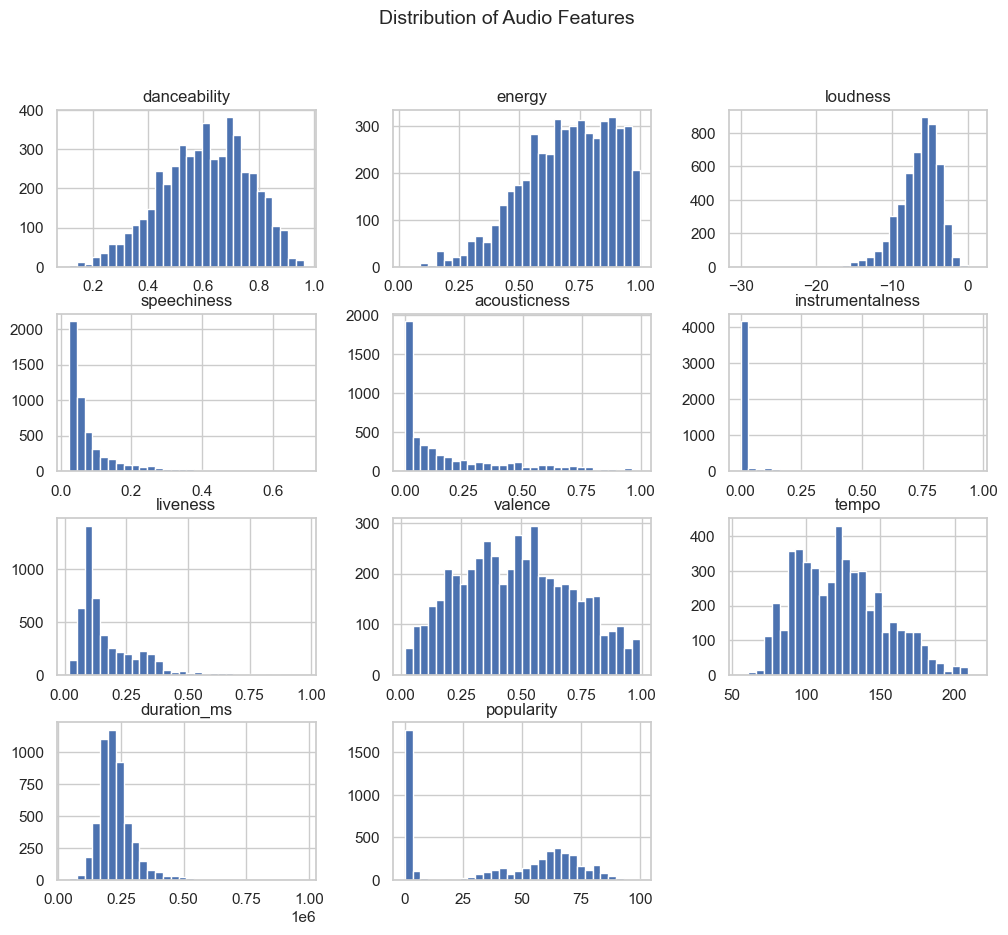

In [15]:
# Plot histograms for the main numerical audio features

df_numeric.hist(bins=30, figsize=(12,10))

plt.suptitle("Distribution of Audio Features", fontsize=14)
plt.show()

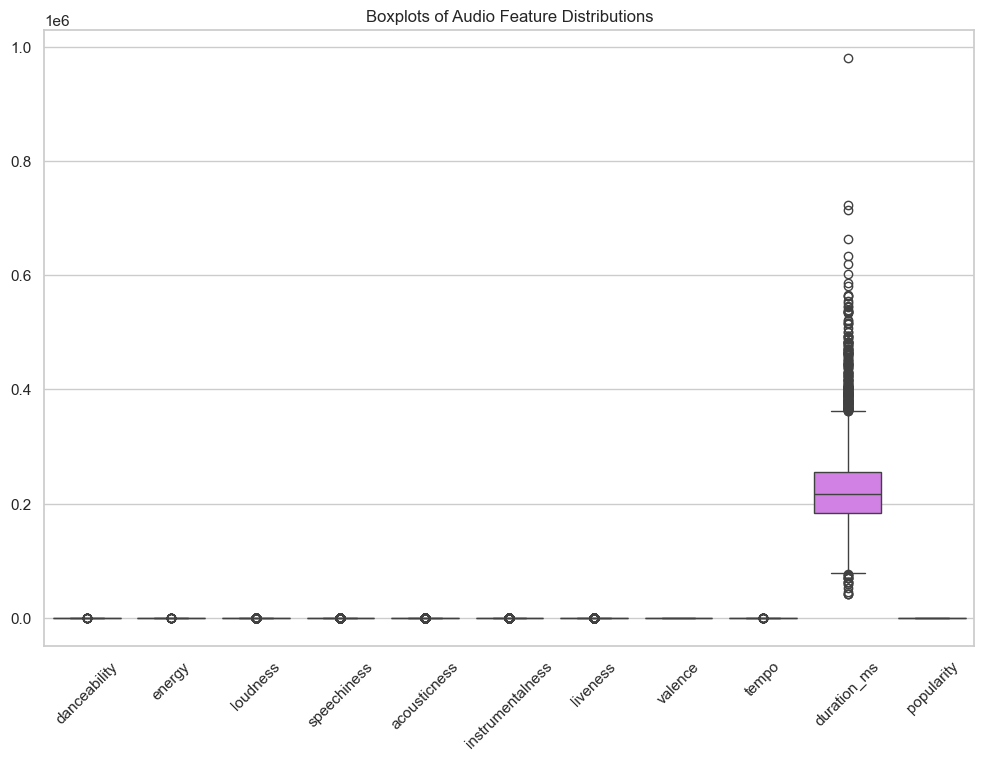

In [16]:
# Create boxplots for the numerical audio features

plt.figure(figsize=(12,8))

sns.boxplot(data=df_numeric)

plt.title("Boxplots of Audio Feature Distributions")
plt.xticks(rotation=45)

plt.show()

The boxplots provide a visual summary of the distribution and variability of the audio feature variables. They also help identify potential outliers and skewed distributions within the dataset. Some variables, such as loudness and tempo, exhibit wider ranges, while others such as danceability and energy appear more concentrated within specific ranges. These observations help guide the interpretation of the dataset and provide context for the statistical analyses that follow.

## Bivariate Analysis

Bivariate analysis examines the relationships between pairs of variables in the dataset. Understanding how variables interact can reveal patterns and dependencies that may not be visible when examining variables individually.

In this section, correlation and covariance are calculated for the numerical variables in the dataset. Visualizations such as heatmaps and scatterplots are also used to illustrate relationships between selected audio features.

In [17]:
# Calculate the covariance matrix for the numerical variables

cov_matrix = df_numeric.cov()

cov_matrix

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
danceability,0.025076,-0.003902,-0.016034,0.002879,0.000492,0.000310,-0.001827,0.012792,-1.150997,-2.709585e+03,0.085722
energy,-0.003902,0.034708,0.342648,0.001258,-0.027875,-0.000900,0.004461,0.008497,0.967150,5.887783e+02,0.035909
loudness,-0.016034,0.342648,7.054153,0.016111,-0.294158,-0.135877,0.048835,0.100462,8.225664,-2.425790e+04,-1.155008
speechiness,0.002879,0.001258,0.016111,0.006007,-0.001020,-0.001171,0.000714,0.001307,0.173470,-7.839914e+02,0.128510
acousticness,0.000492,-0.027875,-0.294158,-0.001020,0.058386,-0.001837,-0.003626,-0.003305,-1.031700,-4.821043e+02,0.439336
instrumentalness,0.000310,-0.000900,-0.135877,-0.001171,-0.001837,0.040600,-0.000545,-0.012148,-0.010577,3.338923e+03,0.247495
liveness,-0.001827,0.004461,0.048835,0.000714,-0.003626,-0.000545,0.020572,0.000159,0.108064,-3.300059e+02,-0.046344
valence,0.012792,0.008497,0.100462,0.001307,-0.003305,-0.012148,0.000159,0.054633,0.214201,-3.927221e+03,-0.776651
tempo,-1.150997,0.967150,8.225664,0.173470,-1.031700,-0.010577,0.108064,0.214201,874.218119,-1.729110e+04,-51.664806
duration_ms,-2709.584797,588.778278,-24257.895462,-783.991393,-482.104307,3338.923343,-330.005946,-3927.220699,-17291.102561,4.811444e+09,221811.879772


In [18]:
# Calculate the Pearson correlation matrix

corr_matrix = df_numeric.corr()

corr_matrix

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
danceability,1.000000,-0.132249,-0.038123,0.234532,0.012859,0.009723,-0.080460,0.345598,-0.245830,-0.246681,0.017145
energy,-0.132249,1.000000,0.692485,0.087117,-0.619210,-0.023984,0.166934,0.195130,0.175577,0.045562,0.006105
loudness,-0.038123,0.692485,1.000000,0.078263,-0.458358,-0.253900,0.128195,0.161827,0.104746,-0.131672,-0.013773
speechiness,0.234532,0.087117,0.078263,1.000000,-0.054490,-0.074987,0.064227,0.072160,0.075697,-0.145827,0.052513
acousticness,0.012859,-0.619210,-0.458358,-0.054490,1.000000,-0.037733,-0.104611,-0.058519,-0.144408,-0.028764,0.057585
instrumentalness,0.009723,-0.023984,-0.253900,-0.074987,-0.037733,1.000000,-0.018850,-0.257933,-0.001775,0.238895,0.038902
liveness,-0.080460,0.166934,0.128195,0.064227,-0.104611,-0.018850,1.000000,0.004730,0.025482,-0.033170,-0.010233
valence,0.345598,0.195130,0.161827,0.072160,-0.058519,-0.257933,0.004730,1.000000,0.030995,-0.242226,-0.105237
tempo,-0.245830,0.175577,0.104746,0.075697,-0.144408,-0.001775,0.025482,0.030995,1.000000,-0.008431,-0.055342
duration_ms,-0.246681,0.045562,-0.131672,-0.145827,-0.028764,0.238895,-0.033170,-0.242226,-0.008431,1.000000,0.101278


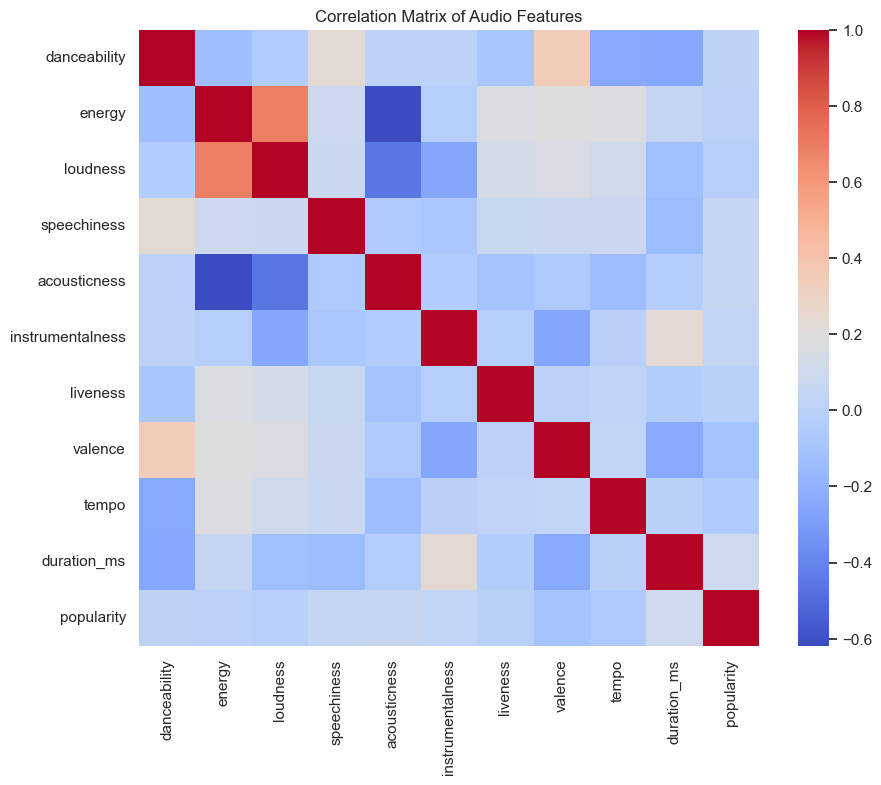

In [19]:
# Visualize the correlation matrix using a heatmap

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)

plt.title("Correlation Matrix of Audio Features")

plt.show()

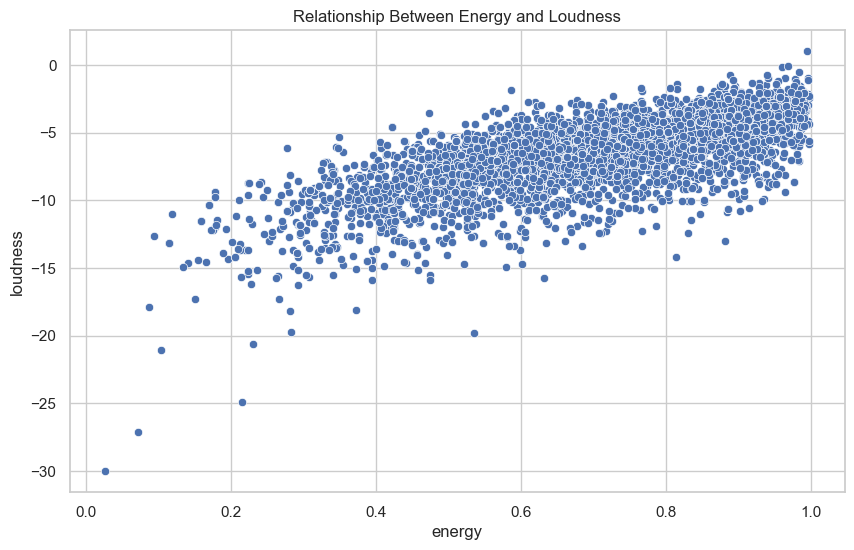

In [20]:
# Create a scatterplot to examine the relationship between energy and loudness

sns.scatterplot(data=df_filtered, x="energy", y="loudness")

plt.title("Relationship Between Energy and Loudness")

plt.show()

The covariance and correlation matrices provide insight into how the audio feature variables relate to one another. The heatmap visualization highlights the strength and direction of these relationships. For example, energy and loudness often exhibit a strong positive relationship, which is expected because louder songs tend to have higher perceived intensity.

These relationships help provide context for the statistical testing and modeling steps that follow in the analysis.

## Hypothesis Testing

Hypothesis testing is used to determine whether observed differences in the data are statistically significant or if they may have occurred by chance. In this section, statistical tests are performed to examine whether certain audio features differ significantly across music genres.

A one-way ANOVA test is used to determine whether the mean values of selected audio features differ across the five genres included in the dataset: Metal, Rock, Pop, Hip Hop, and Electronic. ANOVA is appropriate in this case because it compares the means of more than two independent groups.

### Hypotheses

Null Hypothesis (H0):
The mean energy level is the same across all genres.

Alternative Hypothesis (H1):
At least one genre has a different mean energy level.

In [21]:
# Separate the energy values for each genre

metal_energy = df_filtered[df_filtered['track_genre'] == 'metal']['energy']
rock_energy = df_filtered[df_filtered['track_genre'] == 'rock']['energy']
pop_energy = df_filtered[df_filtered['track_genre'] == 'pop']['energy']
hiphop_energy = df_filtered[df_filtered['track_genre'] == 'hip-hop']['energy']
electronic_energy = df_filtered[df_filtered['track_genre'] == 'electronic']['energy']

In [22]:
# Perform one-way ANOVA to compare energy levels across genres

anova_result = stats.f_oneway(
    metal_energy,
    rock_energy,
    pop_energy,
    hiphop_energy,
    electronic_energy
)

anova_result

F_onewayResult(statistic=252.67594033590822, pvalue=5.670668368809148e-198)

The ANOVA test was conducted to determine whether mean energy levels differ across the five selected genres. The test produced an F-statistic of approximately 252.68 and a p-value that is extremely close to zero.

Because the p-value is much smaller than the significance level of 0.05, the null hypothesis (H0) is rejected. This indicates that there are statistically significant differences in the mean energy levels among at least some of the genres in the dataset.

This result suggests that musical genre plays an important role in the distribution of energy values among songs.

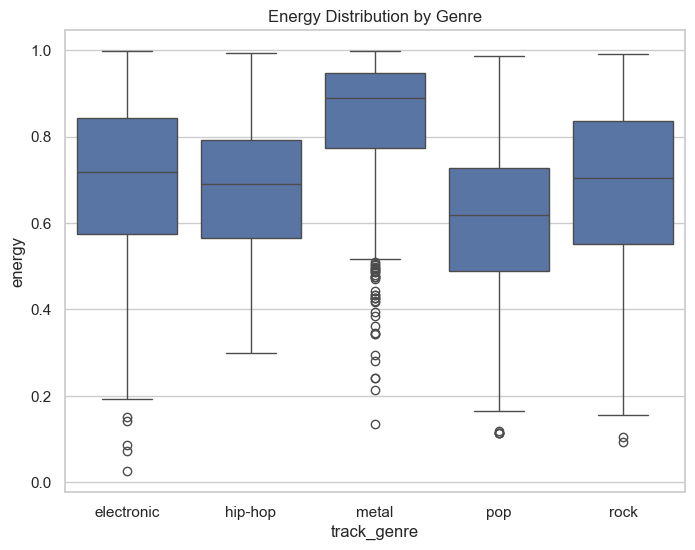

In [23]:
# Visualize energy distribution by genre

plt.figure(figsize=(8,6))

sns.boxplot(data=df_filtered, x='track_genre', y='energy')

plt.title("Energy Distribution by Genre")

plt.show()

## Regression Analysis

Regression analysis is used to examine relationships between a dependent variable and one or more independent variables. In this section, a linear regression model is used to explore whether audio features can help predict the popularity of songs.

The model uses several numerical audio characteristics, such as energy, danceability, loudness, and tempo, as predictor variables. Popularity is used as the target variable. This analysis helps determine whether these audio features are associated with higher or lower popularity scores.

In [24]:
# Define the predictor variables (X) and the target variable (y)

X = df_filtered[
    [
        'danceability',
        'energy',
        'loudness',
        'speechiness',
        'acousticness',
        'instrumentalness',
        'liveness',
        'valence',
        'tempo'
    ]
]

y = df_filtered['popularity']

In [25]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
# Create and train the linear regression model

reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

LinearRegression()

In [27]:
# Predict popularity values using the test data

y_pred = reg_model.predict(X_test)

In [28]:
# Calculate the R-squared value for the model

r2_score = reg_model.score(X_test, y_test)

r2_score

0.009779626303445643

In [29]:
# Display regression coefficients for each feature

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": reg_model.coef_
})

coefficients

,Feature,Coefficient
0,danceability,10.604362
1,energy,24.832255
2,loudness,-0.488618
3,speechiness,23.843063
4,acousticness,15.732819
5,instrumentalness,-0.326106
6,liveness,-2.919985
7,valence,-20.694342
8,tempo,-0.043381


The regression model was used to evaluate whether selected audio features can help predict song popularity. The model produced an R-squared value that represents the proportion of variation in popularity explained by the predictor variables.

Because music popularity is influenced by many factors beyond audio characteristics, it is expected that the model will explain only a portion of the variation in popularity. However, the regression results still provide insight into how certain musical features may be associated with popularity levels.

## Classification Model

Classification models are used to predict categorical outcomes based on input variables. In this section, a logistic regression model is used to classify songs into their respective genres using selected audio features as predictor variables.

The model attempts to learn patterns in features such as energy, danceability, loudness, and tempo in order to determine which genre a song most likely belongs to. Because the predictor variables are measured on different scales, standardization is applied before fitting the logistic regression model. This helps improve model performance and allows the algorithm to converge more effectively.

Evaluating the performance of this model helps determine how well these audio characteristics distinguish between different musical genres.

In [30]:
# Define predictor variables and the target variable for classification

X = df_filtered[
    [
        'danceability',
        'energy',
        'loudness',
        'speechiness',
        'acousticness',
        'instrumentalness',
        'liveness',
        'valence',
        'tempo'
    ]
]

y = df_filtered['track_genre']

In [31]:
# Standardize the predictor variables so they are on a similar scale

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Train a logistic regression classification model

classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [33]:
# Predict genre labels for the test dataset

y_pred = classifier.predict(X_test_scaled)

In [34]:
# Calculate classification accuracy

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.222

The logistic regression model was used to classify songs into their respective genres based on selected audio features. The model achieved an accuracy of approximately 52%, indicating that the audio characteristics provide some ability to distinguish between genres.

Although the model performs better than random guessing, the results suggest that audio features alone do not perfectly separate musical genres. Many genres share similar musical characteristics, which can make classification difficult. Nevertheless, the model demonstrates that certain audio features contain useful information for identifying genre patterns.

## Clustering Analysis

Clustering is an unsupervised learning technique that groups observations based on similarity between variables. Unlike classification models, clustering does not use labeled outcomes and instead attempts to discover natural groupings within the data.

In this section, K-Means clustering is applied to the audio feature variables to determine whether songs naturally form groups based on their musical characteristics. Because the variables are measured on different scales, the features are standardized before applying the clustering algorithm.

In [35]:
# Select numerical features for clustering

cluster_features = df_filtered[
    [
        'danceability',
        'energy',
        'loudness',
        'speechiness',
        'acousticness',
        'instrumentalness',
        'liveness',
        'valence',
        'tempo'
    ]
]

In [36]:
# Standardize the clustering variables

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_features)

In [37]:
# Apply K-Means clustering

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(cluster_scaled)

clusters[:10]

/Users/adamluna/dsc530/miniconda3/envs/book_env/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([0, 1, 2, 3, 1, 1, 0, 0, 1, 0], dtype=int32)

In [38]:
# Add cluster labels to the dataset

df_filtered['cluster'] = clusters

df_filtered[['track_genre', 'cluster']].head()

/var/folders/rj/sy71wr_10zz_k4501vmj9wqw0000gn/T/ipykernel_7207/881421969.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['cluster'] = clusters


,track_genre,cluster
32000,electronic,0
32001,electronic,1
32002,electronic,2
32003,electronic,3
32004,electronic,1


In [39]:
# Count the number of songs in each cluster

df_filtered['cluster'].value_counts()

cluster
1    1753
2    1454
3     941
4     501
0     351
Name: count, dtype: int64

In [40]:
# Reduce dimensionality using PCA for visualization

pca = PCA(n_components=2)

pca_components = pca.fit_transform(cluster_scaled)

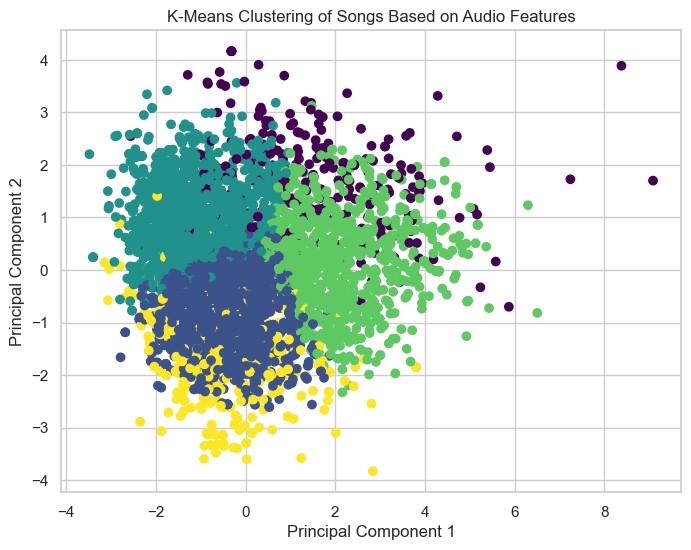

In [41]:
# Plot the clusters using PCA components

plt.figure(figsize=(8,6))

plt.scatter(
    pca_components[:,0],
    pca_components[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("K-Means Clustering of Songs Based on Audio Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

K-Means clustering was used to group songs based on similarities in their audio features. The clustering results show that songs can be grouped into several clusters based on their musical characteristics. However, the clusters do not perfectly correspond to the genre labels, which suggests that many genres share overlapping audio features.

This result highlights that while audio characteristics provide useful information for distinguishing music styles, genre boundaries are not always clearly separated when considering only these variables.

## Conclusion

This exploratory data analysis examined relationships between audio features and musical genres using the Spotify Tracks dataset. Several statistical and machine learning techniques were applied, including descriptive statistics, visualizations, hypothesis testing, regression analysis, classification modeling, and clustering.

The results showed that audio features such as energy and loudness vary significantly across genres. The ANOVA test confirmed that differences in energy levels between genres were statistically significant. The regression model demonstrated that audio characteristics explain some variation in song popularity, although many external factors likely influence popularity as well.

The classification model achieved moderate accuracy when predicting genre from audio features, indicating that these features provide useful but incomplete information for distinguishing between genres. Clustering analysis further showed that songs naturally group together based on their audio characteristics, though these clusters do not perfectly align with genre labels.

Overall, the analysis demonstrates that audio features capture meaningful patterns in musical structure and style. However, the overlap between genres suggests that musical categories are not always clearly separated when considering only quantitative audio characteristics.